In [3]:
import sys
from pathlib import Path

# Allow imports from project root
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

# Plotting config
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "aaa_spread": "#1b9e77",
    "aa_spread":  "#7570b3",
    "bbb_spread": "#d95f02",
    "hy_spread":  "#e7298a",
    "vix":        "#666666",
}

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [4]:
df = pd.read_csv(
    PROJECT_ROOT / "data/processed/master_with_regimes.csv",
    index_col=0, parse_dates=True,
)
trans_matrix = pd.read_csv(PROJECT_ROOT / "results/transition_matrix.csv", index_col=0)
regime_stats = pd.read_csv(PROJECT_ROOT / "results/regime_stats.csv")

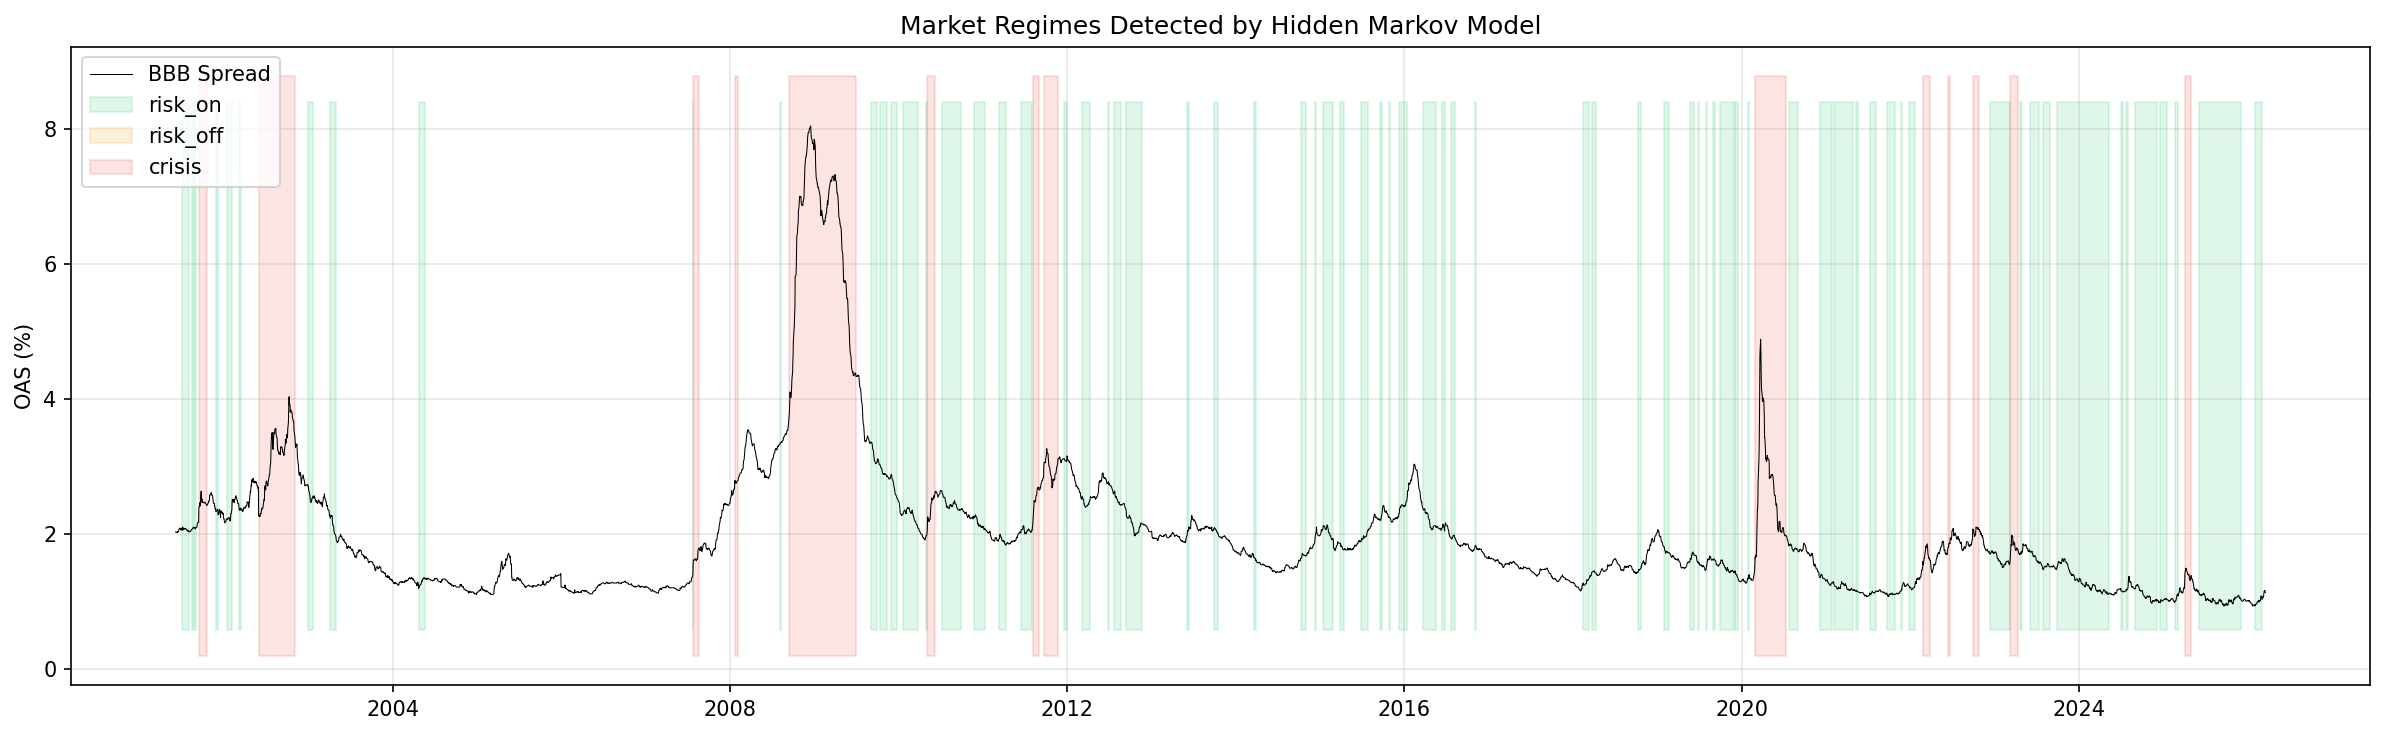

In [5]:
regime_colors = {"risk_on": "#2ecc71", "risk_off": "#f39c12", "crisis": "#e74c3c"}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df["bbb_spread"], color="black", linewidth=0.5, label="BBB Spread")

# Color background by regime
for regime, color in regime_colors.items():
    mask = df["regime"] == regime
    ax.fill_between(df.index, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=mask, alpha=0.15, color=color, label=regime)

ax.set_ylabel("OAS (%)")
ax.set_title("Market Regimes Detected by Hidden Markov Model")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regime_timeline.png", bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for regime, color in regime_colors.items():
    data = df.loc[df["regime"] == regime, "bbb_spread"]
    ax.hist(data, bins=60, alpha=0.5, color=color, label=f"{regime} (n={len(data)})")

ax.set_xlabel("BBB Spread (%)")
ax.set_title("BBB Spread Distribution by Market Regime")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "regime_distributions.png", bbox_inches="tight")
plt.show()